In [1]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

DATA_PATH = "MobiFall_All.csv"
df = pd.read_csv(DATA_PATH)

df = df.sort_values(['subject_id','trial_number','timestamp']).reset_index(drop=True)
df['t_seconds'] = df['timestamp'] / 1e9

df_acc  = df[df['sensor_type'] == 'acc'].reset_index(drop=True)
df_gyro = df[df['sensor_type'] == 'gyro'].reset_index(drop=True)
df_ori  = df[df['sensor_type'] == 'ori'].reset_index(drop=True)

df_acc = df_acc[['timestamp','x','y','z','subject_id','trial_number','category']]
df_gyro = df_gyro[['timestamp','x','y','z','subject_id','trial_number','category']]
df_ori = df_ori[['timestamp','azimuth','pitch','roll','subject_id','trial_number','category']]


print("Accelerometer shape:", df_acc.shape)
print("Gyroscope shape:", df_gyro.shape)
print("Orientation shape:", df_ori.shape)


Accelerometer shape: (1044765, 7)
Gyroscope shape: (2389589, 7)
Orientation shape: (2370472, 7)


In [2]:

print("=== Accelerometer ===")
print(df_acc.isnull().sum())
print("\nCategory counts:")
print(df_acc['category'].value_counts())
print("\n")

print("=== Gyroscope ===")
print(df_gyro.isnull().sum())
print("\nCategory counts:")
print(df_gyro['category'].value_counts())
print("\n")

print("=== Orientation ===")
print(df_ori.isnull().sum())
print("\nCategory counts:")
print(df_ori['category'].value_counts())
print("\n")


=== Accelerometer ===
timestamp       0
x               0
y               0
z               0
subject_id      0
trial_number    0
category        0
dtype: int64

Category counts:
category
ADL     803334
FALL    241431
Name: count, dtype: int64


=== Gyroscope ===
timestamp       0
x               0
y               0
z               0
subject_id      0
trial_number    0
category        0
dtype: int64

Category counts:
category
ADL     1812757
FALL     576832
Name: count, dtype: int64


=== Orientation ===
timestamp       0
azimuth         0
pitch           0
roll            0
subject_id      0
trial_number    0
category        0
dtype: int64

Category counts:
category
ADL     1800394
FALL     570078
Name: count, dtype: int64




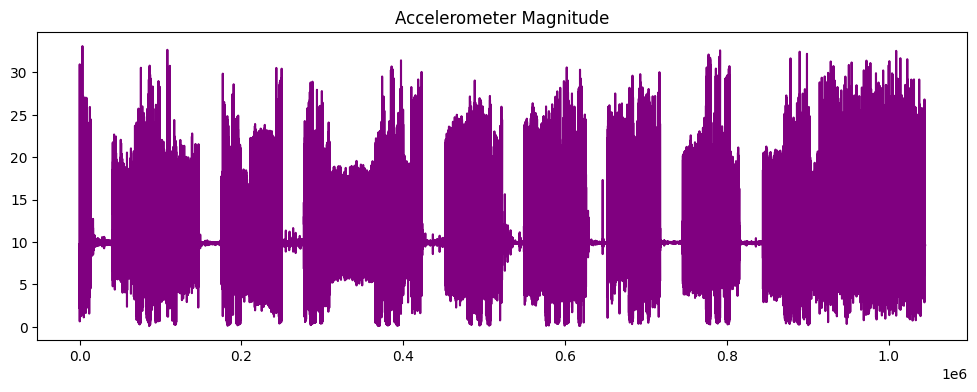

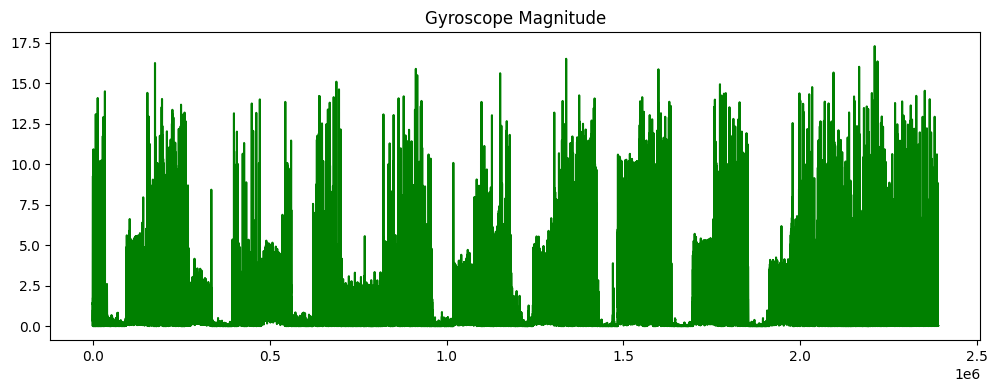

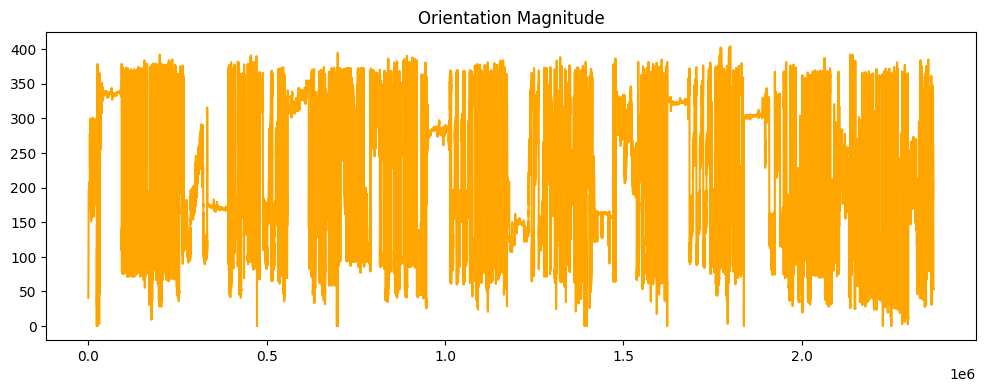

In [8]:
import matplotlib.pyplot as plt
import numpy as np
df_acc['magnitude'] = np.sqrt(df_acc['x']**2 + df_acc['y']**2 + df_acc['z']**2)
df_gyro['magnitude'] = np.sqrt(df_gyro['x']**2 + df_gyro['y']**2 + df_gyro['z']**2)
df_ori['magnitude'] = np.sqrt(df_ori['azimuth']**2 + df_ori['pitch']**2 + df_ori['roll']**2)


plt.figure(figsize=(12,4))
plt.plot(df_acc['magnitude'].values, color='purple')
plt.title('Accelerometer Magnitude')
plt.show()

plt.figure(figsize=(12,4))
plt.plot(df_gyro['magnitude'].values, color='green')
plt.title('Gyroscope Magnitude')
plt.show()

plt.figure(figsize=(12,4))
plt.plot(df_ori['magnitude'].values, color='orange')
plt.title('Orientation Magnitude')
plt.show()


In [9]:
from sklearn.ensemble import IsolationForest
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, precision_score, recall_score, f1_score

X = df_acc.drop(columns=['category'])
y_true = df_acc['category'].apply(lambda x: 1 if x == 'FALL' else 0)

model = IsolationForest(contamination=0.05, random_state=42)
y_pred = model.fit_predict(X)
y_pred = [1 if p == -1 else 0 for p in y_pred]

print("Accuracy:", accuracy_score(y_true, y_pred))
print("Precision:", precision_score(y_true, y_pred))
print("Recall:", recall_score(y_true, y_pred))
print("F1 Score:", f1_score(y_true, y_pred))

print("AUC:", roc_auc_score(y_true, y_pred))
print(confusion_matrix(y_true, y_pred))
print("Total falls: ",sum(y_pred))

Accuracy: 0.7508090336104292
Precision: 0.31895710101648195
Recall: 0.06901350696472285
F1 Score: 0.11347430789661865
AUC: 0.5123634108627287
[[767757  35577]
 [224769  16662]]
Total falls:  52239


In [10]:
from sklearn.ensemble import IsolationForest
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, precision_score, recall_score, f1_score

X = df_gyro.drop(columns=['category'])
y_true = df_gyro['category'].apply(lambda x: 1 if x == 'FALL' else 0)

model = IsolationForest(contamination=0.05, random_state=42)
y_pred = model.fit_predict(X)
y_pred = [1 if p == -1 else 0 for p in y_pred]

print("Accuracy:", accuracy_score(y_true, y_pred))
print("Precision:", precision_score(y_true, y_pred))
print("Recall:", recall_score(y_true, y_pred))
print("F1 Score:", f1_score(y_true, y_pred))

print("AUC:", roc_auc_score(y_true, y_pred))
print(confusion_matrix(y_true, y_pred))
print("Total falls: ",sum(y_pred))

Accuracy: 0.7252155077714201
Precision: 0.16609474389019083
Recall: 0.03440343115499834
F1 Score: 0.05700031020576983
AUC: 0.4897200950403836
[[1713122   99635]
 [ 556987   19845]]
Total falls:  119480


In [11]:
from sklearn.ensemble import IsolationForest
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, precision_score, recall_score, f1_score

X = df_ori.drop(columns=['category'])
y_true = df_ori['category'].apply(lambda x: 1 if x == 'FALL' else 0)

model = IsolationForest(contamination=0.05, random_state=42)
y_pred = model.fit_predict(X)
y_pred = [1 if p == -1 else 0 for p in y_pred]

print("Accuracy:", accuracy_score(y_true, y_pred))
print("Precision:", precision_score(y_true, y_pred))
print("Recall:", recall_score(y_true, y_pred))
print("F1 Score:", f1_score(y_true, y_pred))

print("AUC:", roc_auc_score(y_true, y_pred))
print(confusion_matrix(y_true, y_pred))
print("Total falls: ",sum(y_pred))

Accuracy: 0.7721711119135767
Precision: 0.6266754448158277
Recall: 0.13023831826521984
F1 Score: 0.215657740714599
AUC: 0.552835736726181
[[1756164   44230]
 [ 495832   74246]]
Total falls:  118476


In [12]:
#one class svm

In [ ]:
from sklearn.svm import OneClassSVM
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, fbeta_score, roc_auc_score, confusion_matrix

X = df_acc.drop(columns=['category'])
y_true = df_acc['category'].apply(lambda x: 1 if x == 'FALL' else 0)

model = OneClassSVM(kernel='linear', gamma='auto', nu=0.05)
y_pred = model.fit_predict(X)
y_pred = [1 if p == -1 else 0 for p in y_pred]

print("Accuracy:", accuracy_score(y_true, y_pred))
print("Precision:", precision_score(y_true, y_pred))
print("Recall:", recall_score(y_true, y_pred))
print("F1 Score:", f1_score(y_true, y_pred))
print("F2 Score:", fbeta_score(y_true, y_pred, beta=2))
print("AUC:", roc_auc_score(y_true, y_pred))
print(confusion_matrix(y_true, y_pred))
print("Total falls: ",sum(y_pred))